Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(25059, 35)
   admissions  patients    avg_los  avg_resource
0       25059     10000  10.002793     20.365338


QUESTION 1
HOW EFFICIENTLY IS THE HOSPITAL OPERATING?
  admission_type  admissions    avg_los  median_los
0    OBSERVATION        6236  10.067832        10.0
1         URGENT        6210  10.059581        10.0
2       ELECTIVE        6332   9.993051        10.0
3      EMERGENCY        6281   9.891896        10.0


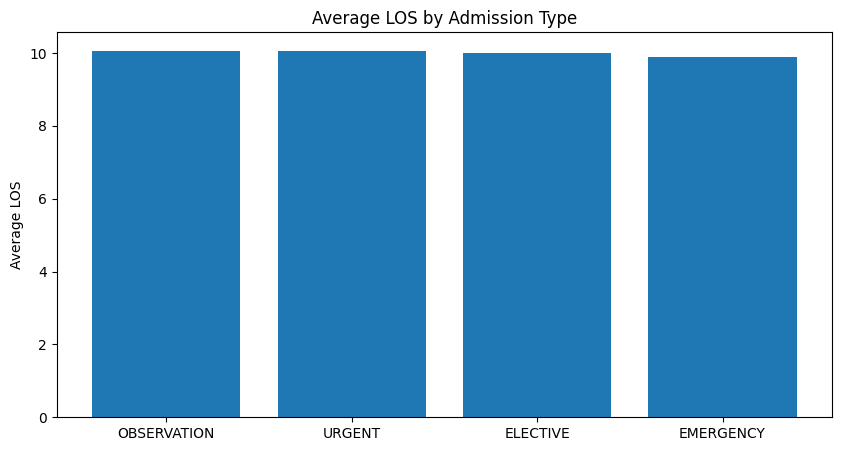

  admission_type  avg_resource
0    OBSERVATION     20.428801
1      EMERGENCY     20.427002
2         URGENT     20.331240
3       ELECTIVE     20.275111


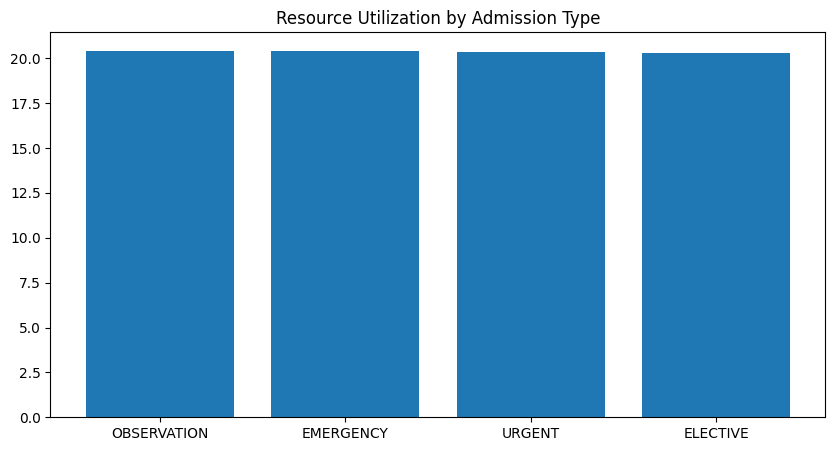

  admission_type  readmission_rate
0         URGENT          0.153623
1      EMERGENCY          0.151727
2    OBSERVATION          0.144965
3       ELECTIVE          0.144188
  admission_type  avg_icu_los
0    OBSERVATION     4.009267
1         URGENT     3.986424
2      EMERGENCY     3.985814
3       ELECTIVE     3.985458

Potential Bottlenecks
  admission_type    avg_los  avg_resource  readmission_rate  avg_icu_los
0    OBSERVATION  10.067832     20.428801          0.144965     4.009267
1         URGENT  10.059581     20.331240          0.153623     3.986424
2       ELECTIVE   9.993051     20.275111          0.144188     3.985458
3      EMERGENCY   9.891896     20.427002          0.151727     3.985814


QUESTION 2
WHICH PATIENT CHARACTERISTICS
ARE ASSOCIATED WITH POOR OUTCOMES?
  age_group  mortality_rate  readmission_rate
0     61-80        0.086541          0.149742
1     41-60        0.085113          0.147787
2       80+        0.082770          0.145692
3     18-40        0.0806

In [ ]:
# =====================================================
# NOTEBOOK 3
# DUCKDB SQL ANALYTICS
# =====================================================

# =====================================================
# SECTION 1: INSTALL DUCKDB
# =====================================================

!pip -q install duckdb

# =====================================================
# SECTION 2: IMPORTS
# =====================================================

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive

drive.mount('/content/drive')

# =====================================================
# SECTION 3: LOAD MASTER DATASET
# =====================================================

DATA_PATH = "/content/drive/MyDrive/synthetic_mimic"

master = pd.read_csv(
    f"{DATA_PATH}/master_dataset.csv"
)

print(master.shape)

master.head()

# =====================================================
# SECTION 4: CREATE DUCKDB DATABASE
# =====================================================

con = duckdb.connect()

con.register(
    "master",
    master
)

# =====================================================
# SECTION 5: DATA OVERVIEW
# =====================================================

query = """
SELECT
COUNT(*) as admissions,
COUNT(DISTINCT subject_id) as patients,
AVG(los_days) as avg_los,
AVG(resource_score) as avg_resource
FROM master
"""

overview = con.execute(
    query
).df()

print(overview)

# =====================================================
# QUESTION 1
# HOSPITAL EFFICIENCY
# =====================================================

print("\n")
print("="*50)
print("QUESTION 1")
print("="*50)
print("HOW EFFICIENTLY IS THE HOSPITAL OPERATING?")
print("="*50)

# =====================================================
# LOS BY ADMISSION TYPE
# =====================================================

los_query = """

SELECT
admission_type,
COUNT(*) admissions,
AVG(los_days) avg_los,
MEDIAN(los_days) median_los

FROM master

GROUP BY admission_type

ORDER BY avg_los DESC

"""

los_df = con.execute(
    los_query
).df()

print(los_df)

# =====================================================
# VISUALIZATION
# =====================================================

plt.figure(figsize=(10,5))

plt.bar(
    los_df["admission_type"],
    los_df["avg_los"]
)

plt.title(
    "Average LOS by Admission Type"
)

plt.ylabel(
    "Average LOS"
)

plt.show()

# =====================================================
# RESOURCE UTILIZATION
# =====================================================

resource_query = """

SELECT

admission_type,

AVG(resource_score) avg_resource

FROM master

GROUP BY admission_type

ORDER BY avg_resource DESC

"""

resource_df = con.execute(
    resource_query
).df()

print(resource_df)

plt.figure(figsize=(10,5))

plt.bar(
    resource_df["admission_type"],
    resource_df["avg_resource"]
)

plt.title(
    "Resource Utilization by Admission Type"
)

plt.show()

# =====================================================
# READMISSION ANALYSIS
# =====================================================

readmit_query = """

SELECT

admission_type,

AVG(readmit_30d) readmission_rate

FROM master

GROUP BY admission_type

ORDER BY readmission_rate DESC

"""

readmit_df = con.execute(
    readmit_query
).df()

print(readmit_df)

# =====================================================
# ICU UTILIZATION
# =====================================================

icu_query = """

SELECT

admission_type,

AVG(icu_los) avg_icu_los

FROM master

GROUP BY admission_type

ORDER BY avg_icu_los DESC

"""

icu_df = con.execute(
    icu_query
).df()

print(icu_df)

# =====================================================
# BOTTLENECK RANKING
# =====================================================

bottleneck_query = """

SELECT

admission_type,

AVG(los_days) avg_los,

AVG(resource_score) avg_resource,

AVG(readmit_30d) readmission_rate,

AVG(icu_los) avg_icu_los

FROM master

GROUP BY admission_type

ORDER BY avg_los DESC

"""

bottlenecks = con.execute(
    bottleneck_query
).df()

print("\nPotential Bottlenecks")

print(bottlenecks)

# =====================================================
# QUESTION 2
# POOR OUTCOMES
# =====================================================

print("\n")
print("="*50)
print("QUESTION 2")
print("="*50)
print("WHICH PATIENT CHARACTERISTICS")
print("ARE ASSOCIATED WITH POOR OUTCOMES?")
print("="*50)

# =====================================================
# AGE ANALYSIS
# =====================================================

age_query = """

SELECT

age_group,

AVG(mortality_90d) mortality_rate,

AVG(readmit_30d) readmission_rate

FROM master

GROUP BY age_group

ORDER BY mortality_rate DESC

"""

age_df = con.execute(
    age_query
).df()

print(age_df)

# =====================================================
# SOFA ANALYSIS
# =====================================================

sofa_query = """

SELECT

sofa,

AVG(mortality_90d) mortality_rate

FROM master

GROUP BY sofa

ORDER BY sofa

"""

sofa_df = con.execute(
    sofa_query
).df()

print(sofa_df)

# =====================================================
# CHARLSON ANALYSIS
# =====================================================

charlson_query = """

SELECT

ROUND(charlson_index) charlson,

AVG(mortality_90d) mortality_rate

FROM master

GROUP BY charlson

ORDER BY charlson

"""

charlson_df = con.execute(
    charlson_query
).df()

print(charlson_df)

# =====================================================
# TOP RISK GROUPS
# =====================================================

risk_query = """

SELECT

age_group,

AVG(mortality_90d) mortality_rate,

AVG(sepsis) sepsis_rate,

AVG(ventilation) ventilation_rate

FROM master

GROUP BY age_group

ORDER BY mortality_rate DESC

"""

risk_df = con.execute(
    risk_query
).df()

print(risk_df)

# =====================================================
# CORRELATION TABLE
# =====================================================

numeric_cols = master.select_dtypes(
    include=np.number
).columns

corr = master[
    numeric_cols
].corr()

mortality_corr = (
    corr["mortality_90d"]
    .sort_values(
        ascending=False
    )
)

print("\nTop Mortality Correlations")

print(
    mortality_corr.head(15)
)

# =====================================================
# EXPORT TABLES
# =====================================================

los_df.to_csv(
    f"{DATA_PATH}/sql_los_analysis.csv",
    index=False
)

resource_df.to_csv(
    f"{DATA_PATH}/sql_resource_analysis.csv",
    index=False
)

bottlenecks.to_csv(
    f"{DATA_PATH}/sql_bottlenecks.csv",
    index=False
)

risk_df.to_csv(
    f"{DATA_PATH}/sql_risk_analysis.csv",
    index=False
)

print("\nExport Complete")

print("""
Created:

sql_los_analysis.csv
sql_resource_analysis.csv
sql_bottlenecks.csv
sql_risk_analysis.csv
""")